In [1]:
import sys
import datacube
import numpy as np
from odc.ui import select_on_a_map
from ipyleaflet import basemaps, basemap_to_tiles

sys.path.append('../../Tools')
from dea_tools.datahandling import load_ard
from dea_tools.datahandling import mostcommon_crs

from dea_tools.plotting import xr_animation
from dea_tools.coastal import tidal_tag
from skimage.color import rgb2hsv, hsv2rgb

def hue_sat_val(rgb_array,
                hue_mult=1, 
                sat_mult=0.8, 
                val_mult=1):   
    
    # Convert to HSV and multiply bands
    hsv_array = rgb2hsv(rgb_array)
    hsv_array[:, :, 0] = hsv_array[:, :, 0] * hue_mult
    hsv_array[:, :, 1] = hsv_array[:, :, 1] * sat_mult
    hsv_array[:, :, 2] = hsv_array[:, :, 2] * val_mult
    
    # Convert back to RGB
    return hsv2rgb(hsv_array.clip(0, 1))


dc = datacube.Datacube(app='Animated timeseries' )

%load_ext autoreload
%autoreload 2

In [2]:
# Configure local dask cluster
from dea_tools.dask import create_local_dask_cluster
create_local_dask_cluster()

# # Create dask gateway cluser
# from dea_tools.dask import create_dask_gateway_cluster
# cluster = create_dask_gateway_cluster()

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/8787/status,
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/8787/status,Workers: 1
Total threads: 31,Total memory: 237.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46739,Workers: 1
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/8787/status,Total threads: 31
Started: Just now,Total memory: 237.21 GiB
Comm: tcp://127.0.0.1:40397,Total threads: 31
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/41961/status,Memory: 237.21 GiB
Nanny: tcp://127.0.0.1:38763,


In [24]:
from odc.ui import select_on_a_map
from ipyleaflet import basemaps, basemap_to_tiles

# Plot interactive map to select area
basemap = basemap_to_tiles(basemaps.Esri.WorldImagery)
geopolygon = select_on_a_map(height='600px',
                             layers=(basemap,),
                             center=(-26, 135), 
                             zoom=4) 

Map(center=[-26, 135], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_t…

In [25]:
# Input params
bands=['nbart_red', 'nbart_green', 'nbart_blue']
time = ('1988', '2023')

# Landsat, native res
crs = mostcommon_crs(dc=dc, 
                     product='ga_ls5t_ard_3', 
                     query={'time': '1990', 
                            'geopolygon': geopolygon})

query = {
    'geopolygon': geopolygon,
    'time': time,
    'measurements': bands,
    'resampling': {'fmask': 'nearest', 
                   'oa_fmask': 'nearest', 
                   '*': 'cubic'},
    'output_crs': crs,
    'resolution': (-10, 10),
    'group_by': 'solar_day',
    'dask_chunks': {'x': 2048, 'y': 2048}
}


/env/lib/python3.10/site-packages/dea_tools/datahandling.py:605: UserWarning: Multiple UTM zones ['epsg:32655', 'epsg:32654'] were returned for this query. Defaulting to the most common zone: epsg:32654
  warnings.warn(


In [30]:
# Load data
ds = load_ard(
    dc=dc,
    products=[
        "ga_ls5t_ard_3",
        "ga_ls7e_ard_3",
        "ga_ls8c_ard_3",
        "ga_ls9c_ard_3",
        "ga_s2am_ard_3",
        "ga_s2bm_ard_3",
    ],
    min_gooddata=0.9,
    # cloud_cover=(0, 20),
    ls7_slc_off=False,
    mask_pixel_quality=True,
    dtype='float32',
    **query
)

# Optionally apply tide filtering
# ds = tidal_tag(ds)
# ds = ds.sel(time = ds.tide_height < ds.tide_height.median())

# Load using dask
ds = ds.compute()
ds

/env/lib/python3.10/site-packages/dea_tools/datahandling.py:276: UserWarning: You have selected a combination of Landsat and Sentinel-2 products. This can produce unexpected results as these products use the same names for different spectral bands (e.g. Landsat and Sentinel-2's 'nbart_swir_2'); use with caution.
  warnings.warn(


Finding datasets
    ga_ls5t_ard_3
    ga_ls7e_ard_3 (ignoring SLC-off observations)
    ga_ls8c_ard_3
    ga_ls9c_ard_3
    ga_s2am_ard_3
    ga_s2bm_ard_3
Counting good quality pixels for each time step using fmask


/env/lib/python3.10/site-packages/distributed/client.py:3161: UserWarning: Sending large graph of size 15.81 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


Filtering to 164 out of 1611 time steps with at least 90.0% good quality pixels
Applying fmask pixel quality/cloud mask
Returning 164 time steps as a dask array


2024-08-29 05:29:02,029 - distributed.utils_perf - WARNING - full garbage collections took 35% CPU time recently (threshold: 10%)
2024-08-29 05:29:05,707 - distributed.utils_perf - WARNING - full garbage collections took 35% CPU time recently (threshold: 10%)


<xarray.Dataset> Size: 2GB
Dimensions:      (time: 164, y: 809, x: 1021)
Coordinates:
  * time         (time) datetime64[ns] 1kB 1988-06-01T23:58:04.603606 ... 202...
  * y            (y) float64 6kB -1.492e+06 -1.492e+06 ... -1.5e+06 -1.5e+06
  * x            (x) float64 8kB 7.748e+05 7.748e+05 ... 7.85e+05 7.85e+05
    spatial_ref  int32 4B 32654
Data variables:
    nbart_red    (time, y, x) float32 542MB 282.0 289.0 303.0 ... 277.0 276.0
    nbart_green  (time, y, x) float32 542MB 349.0 376.0 393.0 ... 552.0 552.0
    nbart_blue   (time, y, x) float32 542MB 255.0 248.0 251.0 ... 716.0 714.0
Attributes:
    crs:           epsg:32654
    grid_mapping:  spatial_ref

### Apply rolling median to smooth out noise and focus on change
Also calculates median surface reflectance over entire time series as an input to `match_histograms` which will reduce scene-to-scene variability

In [34]:
# Apply rolling median (or optionally, annual resampling)
# ds_rolling = ds.resample(time='YE').median(dim='time').rolling(time=3, center=True, min_periods=1).mean()
ds_rolling = ds.rolling(time=30, center=True, min_periods=1).median()

# Calculate all of time median
median_array = np.transpose(ds_rolling[bands]
                            .median(dim='time')
                            .to_array().values, 
                            axes=(1, 2, 0))
print(ds_rolling)
# ds_rolling = ds

<xarray.Dataset> Size: 2GB
Dimensions:      (time: 164, y: 809, x: 1021)
Coordinates:
  * time         (time) datetime64[ns] 1kB 1988-06-01T23:58:04.603606 ... 202...
  * y            (y) float64 6kB -1.492e+06 -1.492e+06 ... -1.5e+06 -1.5e+06
  * x            (x) float64 8kB 7.748e+05 7.748e+05 ... 7.85e+05 7.85e+05
    spatial_ref  int32 4B 32654
Data variables:
    nbart_red    (time, y, x) float32 542MB 357.5 353.0 354.5 ... 278.0 277.0
    nbart_green  (time, y, x) float32 542MB 445.0 447.5 450.5 ... 707.0 728.5
    nbart_blue   (time, y, x) float32 542MB 258.5 252.0 270.0 ... 777.5 774.0
Attributes:
    crs:           epsg:32654
    grid_mapping:  spatial_ref


In [42]:
ds_test = ds_rolling.resample(time="3M").mean()

/env/lib/python3.10/site-packages/xarray/core/groupby.py:668: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index_grouper = pd.Grouper(


In [50]:
ds_test = ds_rolling.interp(time=pd.date_range(ds_rolling.time[0].item(), ds_rolling.time[-1].item(), 200), method="linear")

## Specialised animations

### DEA CoastLines animations

In [35]:
import geopandas as gpd
import pandas as pd
import matplotlib
from shapely.geometry import box, Point

# Get bounding box of data
xmin, ymin, xmax, ymax = ds.geobox.geographic_extent.boundingbox

bounds = [xmin, ymin, xmax, ymax]
bbox = gpd.GeoDataFrame(geometry=[box(*bounds)], 
                        crs='EPSG:4326')

# Set up WFS requests for annual coastlines & rates of change statistics
deacl_coastlines_wfs = 'https://geoserver.dea.ga.gov.au/geoserver/wfs?' \
                       'service=WFS&version=1.1.0&request=GetFeature&' \
                       'typeName=dea:shorelines_annual&maxFeatures=1000&' \
                      f'bbox={ymin},{xmin},{ymax},{xmax},urn:ogc:def:crs:EPSG:4326'

# # Load data from WFS and set CRS
deacl_gdf = gpd.read_file(deacl_coastlines_wfs)
# deacl_gdf = gpd.read_file('/g/data/r78/DEACoastlines/DEACoastlines_annualcoastlines_v1.1.4.shp', bbox=bbox)
deacl_gdf.crs = 'EPSG:3577'

# Clip to extent of satellite data
bbox = gpd.GeoDataFrame(geometry=[ds.geobox.extent.geom],
                        crs=ds.geobox.crs)  
deacl_gdf = gpd.overlay(deacl_gdf, bbox.to_crs(deacl_gdf.crs))
deacl_gdf = deacl_gdf.dissolve('year')

# Create a custom colormap based on 'inferno' with custom color at end
colors = matplotlib.cm.inferno(np.linspace(0, 1, len(deacl_gdf.index) - 1))
colors = np.vstack((colors, matplotlib.colors.to_rgba('#ffffe1')))
custom_cmap = matplotlib.colors.ListedColormap(colors)

# Apply colours
norm = matplotlib.colors.Normalize(vmin=0, vmax=len(deacl_gdf.index))
rgba = custom_cmap(norm(deacl_gdf.reset_index().index))
deacl_gdf['color'] = list(rgba)
deacl_gdf['start_time'] = (pd.to_datetime(deacl_gdf.index.astype(int), format="%Y") + pd.DateOffset(months=6))
# deacl_gdf['end_time'] = (pd.to_datetime(deacl_gdf.index.astype(int) + 1, format="%Y") + pd.DateOffset(months=6))

# # Remove a year
# # deacl_gdf = deacl_gdf.drop('1993')


/env/lib/python3.10/site-packages/dea_tools/plotting.py:502: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  gdf[time_col] = pd.to_datetime(gdf[time_col], errors='ignore')
/env/lib/python3.10/site-packages/dea_tools/plotting.py:502: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  gdf[time_col] = pd.to_datetime(gdf[time_col], errors='ignore')


Applying custom image processing functions


  0%|          | 0/200 (0.0 seconds remaining at ? frames/s)

Exporting animation to deacoastlines_annual_testing.mp4


  0%|          | 0/200 (0.0 seconds remaining at ? frames/s)

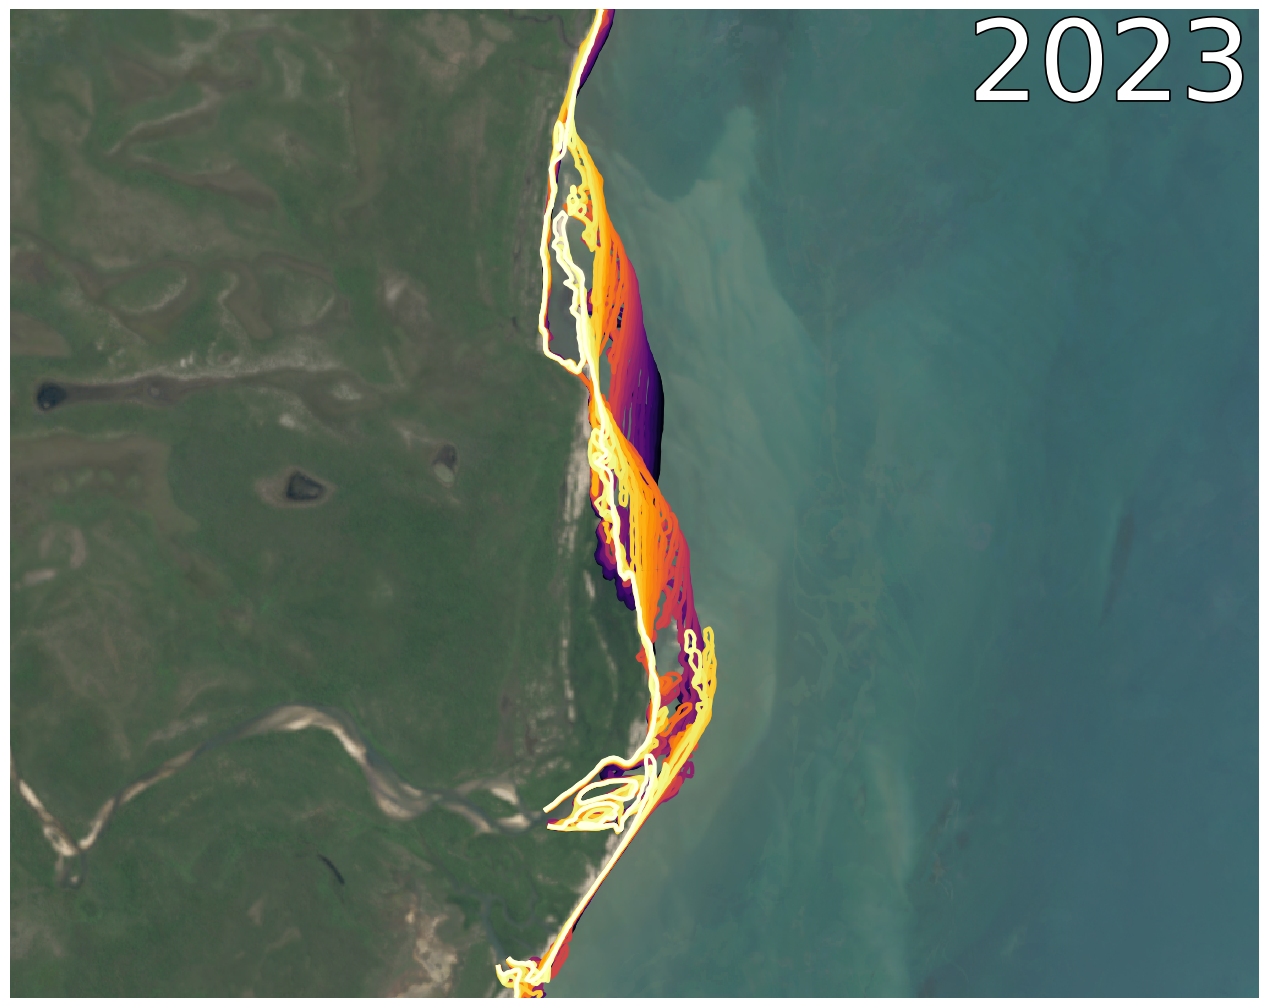

In [51]:
import numpy as np
from skimage.filters import unsharp_mask
from skimage.exposure import match_histograms, rescale_intensity, adjust_sigmoid

site = "testing"

funcs_list = [# lambda x: match_histograms(image=x, reference=median_array, channel_axis=True),
              rescale_intensity,
#               hue_sat_val,
              # lambda x: unsharp_mask(x, radius=20, amount=0.2),
              # lambda x: unsharp_mask(x, radius=5, amount=0.2),
              lambda x: x**0.5,
#               lambda x: adjust_sigmoid(image=x, cutoff=0.7, gain=3)
             ]
# funcs_list = None

xr_animation(output_path=f'deacoastlines_annual_{site}.mp4',
             ds=ds_test,  #rolling,
             show_text="",
             bands=bands,
             interval=30,
             width_pixels=900,
             percentile_stretch=(0.05, 0.999),
             image_proc_funcs=funcs_list,
             show_date='%Y',
             annotation_kwargs={'fontsize': 80},
             show_gdf=deacl_gdf,
             gdf_kwargs = {'linewidth': 3},
#              imshow_kwargs={'vmin': -0.5, 'vmax': 0.7},   # Stuart Point, Twilight Bay
             imshow_kwargs={'vmin': -0.1, 'vmax': 1.1},
             # limit=10,
            ) 

In [ ]:
!ffmpeg -y -i deacoastlines_annual_{site}.mp4 -i deacoastlines_inset_{site}.png \
-filter_complex "[0:v][1:v] overlay=0:0:enable='between(t,0,20)'" \
-pix_fmt yuv420p -c:a copy \
temp.mp4

!ffmpeg -y -i temp.mp4 -filter_complex "[0]trim=0:2[hold],[0][hold]concat[extended],[extended][0]overlay" -pix_fmt yuv420p -c:a copy deacoastlines_annualwithinset_{site}.mp4

In [ ]:
!ffmpeg -y -i 'Landsat 5 7 8 - 1987-2019 - Corner Inlet - True colour animation.mp4' -i seminar_title.png \
-filter_complex "[0:v][1:v] overlay=0:0:enable='between(t,0,20)'" \
-pix_fmt yuv420p -c:a copy \
seminar_with_title.mp4

### Animated fade

In [ ]:
import imageio
import numpy as np

from_array = imageio.imread('tides_fade/tides_low.png')
to_array = imageio.imread('tides_fade/tides_high.png')

framerate = 30
pause = 3500
frames = 20

stacked_from_to = np.stack([to_array, from_array], axis=3)

intervals = np.linspace(0, 1.0, frames + 1).tolist()
weights = intervals + intervals[::-1][1:-1]
milliseconds = [pause] + [framerate] * (len(intervals) - 2) + [pause] + [framerate] * (len(intervals) - 2)
# weights = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.0]
# milliseconds = [50, 50, 50, 50, 50, 50, 50, 50, 50, 3500, 50, 50, 50, 50, 50, 50, 50, 50, 50, 3500]

for i, weight in enumerate(weights):

    ave_from_to = np.average(stacked_from_to, axis=3, weights=np.array([weight, 1.0 - weight]))
    imageio.imwrite(f'tides_fade/output_{i}_({milliseconds[i]}ms).png', ave_from_to.astype(np.uint8))


### Mangrove animation

In [ ]:
import numpy as np
from skimage.filters import unsharp_mask
from skimage.exposure import match_histograms, rescale_intensity, adjust_sigmoid

ndvi = (d
        
        
        
        s_rolling["nbart_nir"] - ds_rolling["nbart_red"])/(ds_rolling["nbart_nir"] + ds_rolling["nbart_red"])
ds_rolling2 = ds_rolling * rescale_intensity(image=ndvi, in_range=(0, 0.8), out_range=(0, 1.0))



In [ ]:

funcs_list = [
#               lambda x: match_histograms(image=x, reference=median_array, multichannel=True),
#               lambda x: x**0.8,
#               ndvi_mult,
              rescale_intensity,
#               hue_sat_val,
#               lambda x: unsharp_mask(x, radius=20, amount=0.2),
#               lambda x: unsharp_mask(x, radius=5, amount=0.1),
#               lambda x: adjust_sigmoid(image=x, cutoff=0.7, gain=3)
             ]
funcs_list = None

xr_animation(output_path='animation_bowling.mp4',
             ds=ds_rolling2.isel(time=slice(20, -10)),
             show_text='',
             bands=bands[0:3],
             interval=50,
             width_pixels=900,
             percentile_stretch=(0.001, 0.999),
             image_proc_funcs=funcs_list,
             show_date='%Y',
             annotation_kwargs={'fontsize': 60},
#              show_gdf=deacl_gdf,
#              gdf_kwargs = {'linewidth': 2.5},
#              imshow_kwargs={'vmin': -0.5, 'vmax': 0.7},   # Stuart Point, Twilight Bay
#              imshow_kwargs={'vmin': -0.2, 'vmax': 0.6},
#              limit=20,
            ) 